<div style='color: #216969;
           background-color: #EAF6F6;
           font-size: 200%;
           border-radius:15px;
           text-align:center;
           font-weight:600;
           border-style: solid;
           border-color: dark green;
           font-family: "Cambria";'>
XGBClassifier...
<a class="anchor" id="1"></a> 


In [17]:
! pip uninstall xgboost -y
! pip install xgboost==2.1.4


Found existing installation: xgboost 3.0.0
Uninstalling xgboost-3.0.0:
  Successfully uninstalled xgboost-3.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 35.3 MB/s eta 0:00:0000:0100:01


In [18]:
import xgboost # Import the xgboost package
print(xgboost.__file__)  # Path to the installed package

/home/codespace/.python/current/lib/python3.12/site-packages/xgboost/__init__.py


In [19]:
import sklearn # Import the sklearn package
print(sklearn.__version__)  # Should be 1.4.x or higher

1.6.1


In [20]:
# Importing necessary libraries

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # for data visualization purposes
import seaborn as sns # for statistical data visualization
%matplotlib inline



In [21]:
import warnings
warnings.filterwarnings('ignore') # ignore warnings

In [22]:
# Read the dataset
df = pd.read_csv("../data/adult.csv") #, sep=',\s')
df.head()

,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


![](../../imgs/featureEngin.png)

In [23]:
df.info() # Check for missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32560 entries, 0 to 32559
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   39              32560 non-null  int64 
 1    State-gov      32560 non-null  object
 2    77516          32560 non-null  int64 
 3    Bachelors      32560 non-null  object
 4    13             32560 non-null  int64 
 5    Never-married  32560 non-null  object
 6    Adm-clerical   32560 non-null  object
 7    Not-in-family  32560 non-null  object
 8    White          32560 non-null  object
 9    Male           32560 non-null  object
 10   2174           32560 non-null  int64 
 11   0              32560 non-null  int64 
 12   40             32560 non-null  int64 
 13   United-States  32560 non-null  object
 14   <=50K          32560 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [24]:
# Check for  features' distinct  values
for col in df.select_dtypes("object").columns:
    print(f" {col:-<30} {df[col].nunique()}")

  State-gov-------------------- 9
  Bachelors-------------------- 16
  Never-married---------------- 7
  Adm-clerical----------------- 15
  Not-in-family---------------- 6
  White------------------------ 5
  Male------------------------- 2
  United-States---------------- 42
  <=50K------------------------ 2


In [25]:
# check missing values in numerical variables

df.isnull().sum()

39                0
 State-gov        0
 77516            0
 Bachelors        0
 13               0
 Never-married    0
 Adm-clerical     0
 Not-in-family    0
 White            0
 Male             0
 2174             0
 0                0
 40               0
 United-States    0
 <=50K            0
dtype: int64

In [26]:
df.iloc[:, 1:] # Drop the first column

,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
1,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
2,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
3,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
4,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32555,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32556,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32557,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32558,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [27]:
df.iloc[:, 1:-1].sample() # Drop the last column

,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
26192,Private,114691,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States


In [28]:
df.iloc[:, 1:].sample() # Drop the first column

,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
28921,?,85815,HS-grad,9,Divorced,?,Own-child,Asian-Pac-Islander,Male,0,0,20,United-States,<=50K


In [29]:
# label encoder of the taget F
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df.iloc[:, -1] = le.fit_transform(df.iloc[:, -1])


In [16]:
df.info() # disaplay features informations

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32560 entries, 0 to 32559
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   39              32560 non-null  int64 
 1    State-gov      32560 non-null  object
 2    77516          32560 non-null  int64 
 3    Bachelors      32560 non-null  object
 4    13             32560 non-null  int64 
 5    Never-married  32560 non-null  object
 6    Adm-clerical   32560 non-null  object
 7    Not-in-family  32560 non-null  object
 8    White          32560 non-null  object
 9    Male           32560 non-null  object
 10   2174           32560 non-null  int64 
 11   0              32560 non-null  int64 
 12   40             32560 non-null  int64 
 13   United-States  32560 non-null  object
 14   <=50K          32560 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [30]:
df.iloc[:, -1].sample(5) # Check the target variable

30580    0
30390    1
21926    1
30009    0
4634     0
Name:  <=50K, dtype: object

In [31]:
df = pd.get_dummies(
    df.iloc[:, 1:],  # Exclude Student_ID
    columns=df.iloc[:, 1:].select_dtypes("object").columns,  # Object columns from sliced data
    drop_first=True,  # Avoid multicollinearity
    dtype=int  # Use integers (0/1)
)

![](../../imgs/target.jpeg)

In [ ]:
X = df.iloc[:, :-1] # All Features except the last column

y =df.iloc[:, -1] # Target variable

![](../../imgs/dataSplit.jpg)

![](../../imgs/datSplit.jpg)

In [33]:
# split X and y into training and testing sets

from sklearn.model_selection import train_test_split

# First, split into train (70%) and temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

# Then, split the temp set into validation (50% of temp = 15% of total) and test (50% of temp = 15% of total)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


In [34]:
# check the shape of X_train and X_test

X_train.shape, X_test.shape, X_val.shape

((22792, 99), (4884, 99), (4884, 99))

In [35]:
X_train.head()

,77516,13,2174,0,40,State-gov_ Federal-gov,State-gov_ Local-gov,State-gov_ Never-worked,State-gov_ Private,State-gov_ Self-emp-inc,...,United-States_ Portugal,United-States_ Puerto-Rico,United-States_ Scotland,United-States_ South,United-States_ Taiwan,United-States_ Thailand,United-States_ Trinadad&Tobago,United-States_ United-States,United-States_ Vietnam,United-States_ Yugoslavia
21385,732102,13,0,0,40,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
19749,72887,9,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
1216,163003,9,0,0,41,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
30048,187873,14,0,0,40,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
23077,43764,16,15024,0,50,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0


In [36]:
from xgboost import XGBClassifier
import xgboost
print("XGBoost version:", xgboost.__version__)  # Should print 2.1.4
print("XGBClassifier source:", XGBClassifier.__module__)  # Should print 'xgboost.sklearn'

XGBoost version: 3.0.0
XGBClassifier source: xgboost.sklearn


In [37]:
# Classifier
classifier = XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    eval_metric='mlogloss'
)



In [38]:
# Fit
classifier.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    # early_stopping_rounds=10,
    verbose=True
)

[0]	validation_0-mlogloss:0.99746	validation_1-mlogloss:0.99710
[1]	validation_0-mlogloss:0.78753	validation_1-mlogloss:0.78748
[2]	validation_0-mlogloss:0.65213	validation_1-mlogloss:0.65216
[3]	validation_0-mlogloss:0.55955	validation_1-mlogloss:0.55986
[4]	validation_0-mlogloss:0.49403	validation_1-mlogloss:0.49562
[5]	validation_0-mlogloss:0.44661	validation_1-mlogloss:0.44884
[6]	validation_0-mlogloss:0.41096	validation_1-mlogloss:0.41380
[7]	validation_0-mlogloss:0.38423	validation_1-mlogloss:0.38759
[8]	validation_0-mlogloss:0.36410	validation_1-mlogloss:0.36826
[9]	validation_0-mlogloss:0.34843	validation_1-mlogloss:0.35366
[10]	validation_0-mlogloss:0.33584	validation_1-mlogloss:0.34222
[11]	validation_0-mlogloss:0.32517	validation_1-mlogloss:0.33251
[12]	validation_0-mlogloss:0.31746	validation_1-mlogloss:0.32571
[13]	validation_0-mlogloss:0.30965	validation_1-mlogloss:0.31894
[14]	validation_0-mlogloss:0.30433	validation_1-mlogloss:0.31469
[15]	validation_0-mlogloss:0.29933	

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, num_class=4, ...)

In [39]:
# Step 6: Predict (optional)
y_pred = classifier.predict(X_test)
print("Predictions:", y_pred)

Predictions: [[1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 ...
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]]


In [40]:
eval_result= classifier.evals_result()
training_rounds = range(len(eval_result['validation_0']['mlogloss']))
training_rounds


range(0, 100)

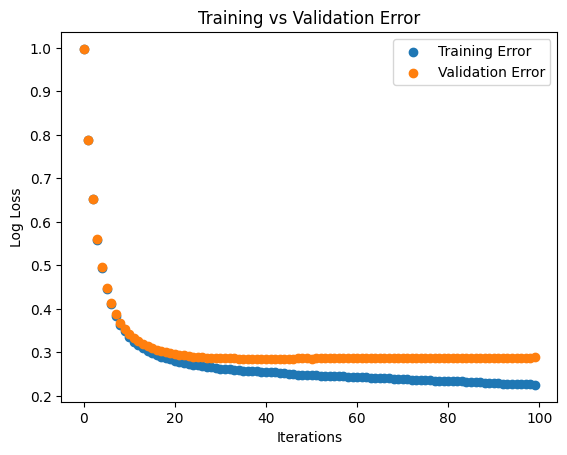

In [42]:
plt.scatter(x=training_rounds, y=eval_result['validation_0']['mlogloss'], label='Training Error')
plt.scatter(x=training_rounds, y=eval_result['validation_1']['mlogloss'], label='Validation Error')
plt.xlabel('Iterations')
plt.ylabel('Log Loss')
plt.title('Training vs Validation Error')
plt.legend()
plt.show()

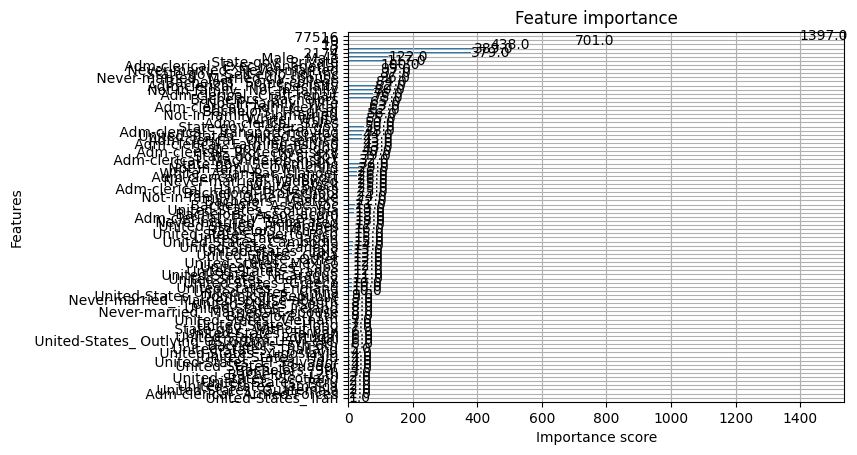

In [43]:
import matplotlib.pyplot as plt
import xgboost as   xgb
xgb.plot_importance(classifier)
plt.show()

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

disp = ConfusionMatrixDisplay.from_estimator(
    classifier,
    X_test,
    y_test,
    cmap=plt.cm.Blues,  # Color map for the plot
    # normalize='true' # Uncomment to display normalized values (percentages)
)
disp.ax_.set_title('Confusion Matrix')
plt.show()

ValueError: Mix type of y not allowed, got types {'binary', 'multilabel-indicator'}

## Early Stop

In [45]:
# Convert data to DMatrix (XGBoost's internal format)
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)

# Define parameters
params = {
    'objective': 'multi:softprob',  # Adjust based on your task
    'eval_metric': 'mlogloss',
      'num_class': 4
}
evals = [(dtrain, 'train'), (dval, 'val')]
print("Starting XGBoost training with early stopping...")
num_boost_round = 100 # Set a sufficiently high number of max rounds
# Train the model
bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=num_boost_round, # Maximum number of boosting rounds
    evals=evals,
    early_stopping_rounds=10, # Stops if 'mlogloss' on 'val' set doesn't improve for 10 rounds
    verbose_eval=10 # Print evaluation results every 10 rounds
    # verbose_eval=True # Print results every round
    # verbose_eval=False # Print only the final results if stopped early
)

Starting XGBoost training with early stopping...
[0]	train-mlogloss:0.99746	val-mlogloss:0.99710
[10]	train-mlogloss:0.33584	val-mlogloss:0.34222
[20]	train-mlogloss:0.28097	val-mlogloss:0.29644
[30]	train-mlogloss:0.26317	val-mlogloss:0.28775
[40]	train-mlogloss:0.25560	val-mlogloss:0.28510
[50]	train-mlogloss:0.24783	val-mlogloss:0.28603


In [46]:
print(f"\nTraining finished.")
if bst.best_iteration != num_boost_round-1 : # Check if early stopping occurred (best_iteration is 0-indexed)
     print(f"Early stopping occurred at round {bst.best_iteration + 1} (best score: {bst.best_score:.4f})")
else:
     print(f"Training completed {bst.num_boosted_rounds()} rounds without early stopping.")



Training finished.
Early stopping occurred at round 42 (best score: 0.2851)


In [47]:
#  prediction (outputs probabilities for multi:softprob)
dtest = xgb.DMatrix(X_test) # Assuming you have X_test
y_pred_proba = bst.predict(dtest, iteration_range=(0, bst.best_iteration + 1))
y_pred_labels = np.argmax(y_pred_proba, axis=1) # To get class labels

In [48]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    log_loss  # Since your eval_metric was mlogloss
)


In [49]:
# a) Accuracy Score
accuracy = accuracy_score(y_test, y_pred_labels)
print(f"\nAccuracy on Test Set: {accuracy:.4f}")


Accuracy on Test Set: 0.8675


In [50]:
# Assuming labels are 0 to num_class-1 as required by XGBoost multi:softprob
logloss = log_loss(y_test, y_pred_proba)
print(f"Log Loss on Test Set: {logloss:.4f}")

ValueError: y_true and y_pred contain different number of classes 2, 4. Please provide the true labels explicitly through the labels argument. Classes found in y_true: [0 1]

In [51]:

print("\nClassification Report:")
print(classification_report(y_test, y_pred_labels))


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      3698
           1       0.79      0.62      0.69      1186

    accuracy                           0.87      4884
   macro avg       0.84      0.78      0.80      4884
weighted avg       0.86      0.87      0.86      4884



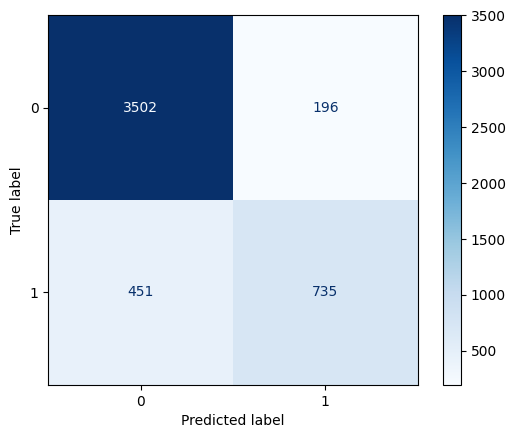

In [52]:
disp = ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred_labels,
        # display_labels=y.unique(), # Use class names if available
        cmap=plt.cm.Blues,
        # normalize='true' # Optional: display percentages
    )

In [ ]:
# plot learning curve


In [ ]:
best_hyperparams = {
    'objective': params.get('objective', 'multi:softprob'),
    'eval_metric': params.get('eval_metric', 'mlogloss'),
    # Translate parameters back if needed:
    'learning_rate': params.get('eta', 0.1), # Example: eta -> learning_rate
    'max_depth': params.get('max_depth', 6),
    'subsample': params.get('subsample', 1.0),
    'colsample_bytree': params.get('colsample_bytree', 1.0),
    'gamma': params.get('gamma', 0),
    'reg_lambda': params.get('lambda', 1), # Example: lambda -> reg_lambda
    'reg_alpha': params.get('alpha', 0),   # Example: alpha -> reg_alpha
    'seed': params.get('seed', 42),
    # Use the optimal number of trees found by early stopping in xgb.train
    # We fit with this specific number inside learning_curve
    'n_estimators': bst.best_iteration + 1,
    # No early stopping here - learning_curve handles the fitting process
}

In [ ]:
# Create an *untrained* instance of the classifier
# For multi-class, objective/eval_metric are often handled automatically,
# but specifying them can ensure consistency. num_class is not needed here.
final_classifier = XGBClassifier(**best_hyperparams)

print("Using XGBClassifier for learning curve with parameters:")
print(final_classifier.get_params()) # Verify parameters

Using XGBClassifier for learning curve with parameters:
{'objective': 'multi:softprob', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 1.0, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'mlogloss', 'feature_types': None, 'gamma': 0, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 6, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 71, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': None, 'reg_alpha': 0, 'reg_lambda': 1, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 1.0, 'tree_method': None, 'validate_parameters': None, 'verbosity': None, 'seed': 42}


In [ ]:
# --- 2. Define Training Sizes and Call learning_curve ---
from sklearn.model_selection import learning_curve

# Define the relative sizes of the training sets to use
# e.g., 10%, 20%, ..., 100% of the training data
train_sizes_abs, train_scores, test_scores = learning_curve(
    estimator=final_classifier,
    X=X_train, # Your full training features
    y=y_train, # Your full training labels
    train_sizes=np.linspace(0.1, 1.0, 10), # 10 steps from 10% to 100%
    cv=5, # Number of cross-validation folds (adjust as needed)
    scoring='accuracy', # Or your primary metric (e.g., 'f1_macro', 'neg_log_loss')
    n_jobs=-1, # Use all available CPU cores
    random_state=42 # Ensure reproducibility of CV splits
)


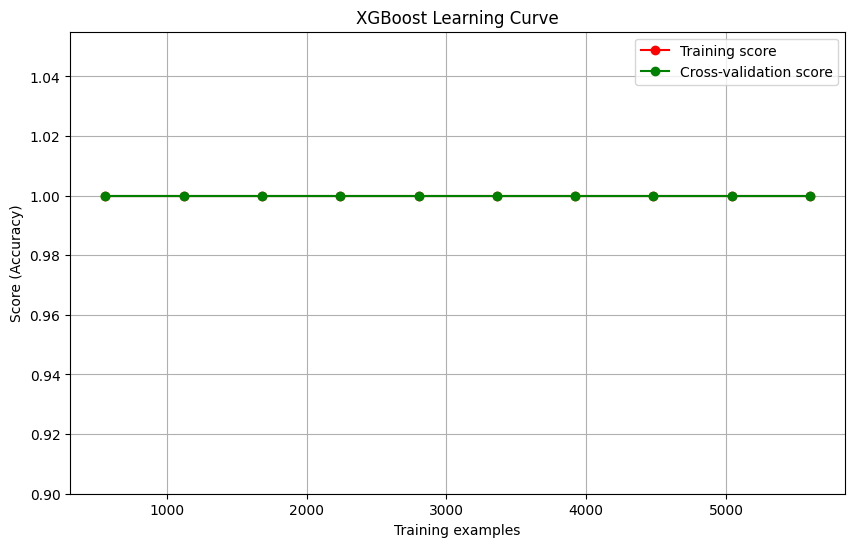

In [ ]:





# --- 3. Calculate Mean and Std Dev for Plotting ---
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# --- 4. Plot the Learning Curve ---
plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes_abs, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes_abs, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="g")

plt.plot(train_sizes_abs, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes_abs, test_scores_mean, 'o-', color="g", label="Cross-validation score")

plt.title('XGBoost Learning Curve')
plt.xlabel('Training examples')
plt.ylabel('Score (Accuracy)')
plt.legend(loc="best")
plt.grid(True)
plt.ylim(bottom=max(0, test_scores_mean.min() - 0.1)) # Adjust y-axis lower limit
plt.show()
